In [3]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     --------------- ------------------------ 30.7/80.3 kB 1.4 MB/s eta 0:00:01
     ---------------------------------------- 80.3/80.3 kB 1.5 MB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/131.7 kB ? eta -:--:--
     -------------------------------------- 131.7/131.7 kB 3.9 MB/s eta 0:00:00
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
     ---------------------------------------- 0.0/61.2 kB ? eta -:--:--
     ---------------------------------------- 61.2/61.2 kB ? eta 0:00:00
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using ca

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- First 5 Rows of Data ---


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


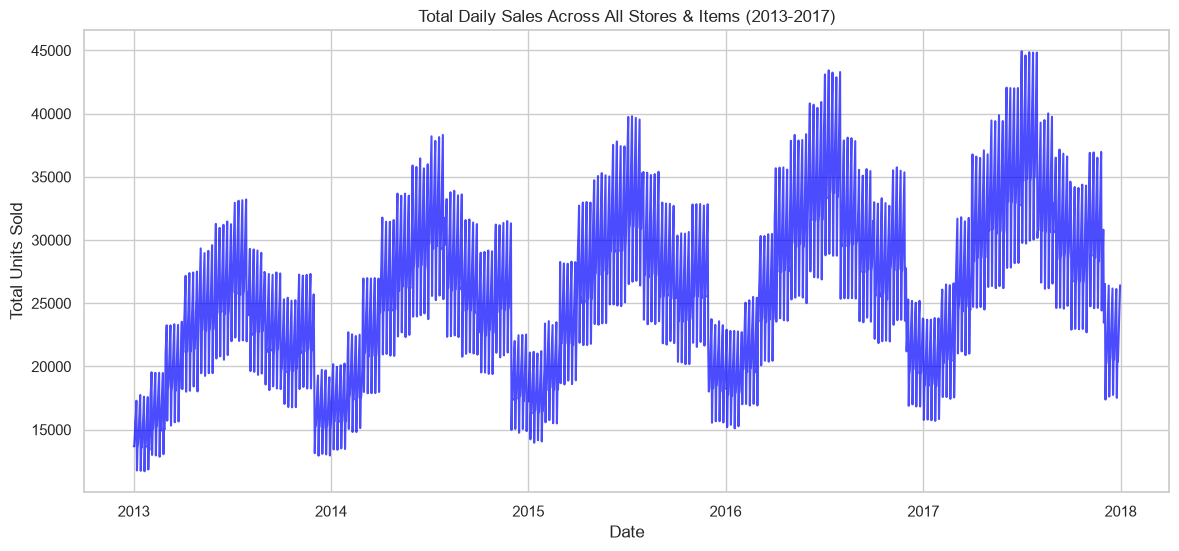

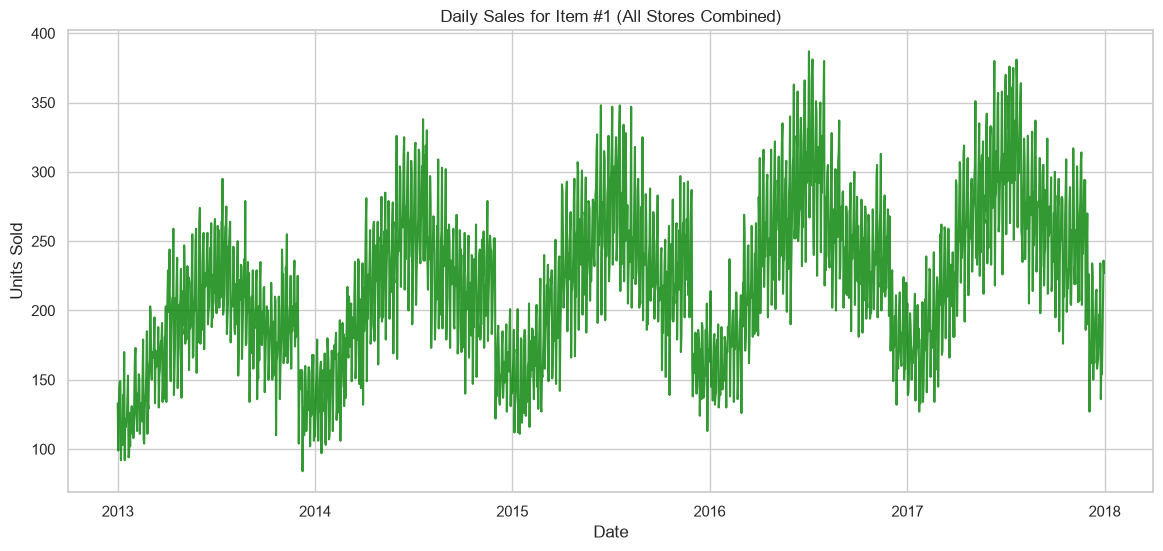

In [4]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# STEP 1: LOAD THE DATA
# ==========================================
# Load the dataset (Make sure train.csv is in the same folder as this notebook)
df = pd.read_csv('train.csv')

# Convert the 'date' column from a string to an actual datetime object
# This is crucial for time-series forecasting!
df['date'] = pd.to_datetime(df['date'])

print("--- First 5 Rows of Data ---")
display(df.head())

print("\n--- Data Info ---")
df.info()

# ==========================================
# STEP 2: BASIC EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Let's look at the total sales over time to spot trends and seasonality
# We will aggregate the sales by date (summing sales across all stores and items)
daily_sales = df.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['sales'], color='blue', alpha=0.7)
plt.title('Total Daily Sales Across All Stores & Items (2013-2017)')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.show()

# Let's look at a single item to see its specific trend
item_1_sales = df[df['item'] == 1].groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(item_1_sales['date'], item_1_sales['sales'], color='green', alpha=0.8)
plt.title('Daily Sales for Item #1 (All Stores Combined)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.show()

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# STEP 5: PREPARE DATA FOR A SINGLE ITEM
# ==========================================
# Let's isolate Store 1, Item 1 to build our first model
df_item = df[(df['store'] == 1) & (df['item'] == 1)].copy()

# Set the date as the index. This is CRITICAL for time-series data!
df_item.set_index('date', inplace=True)

# Ensure we have data for every single day (fill missing days with 0 sales)
df_item = df_item.asfreq('D', fill_value=0)

# ==========================================
# STEP 6: FEATURE ENGINEERING
# ==========================================
# 1. Time-Based Features (Translating dates into numbers the model understands)
df_item['dayofweek'] = df_item.index.dayofweek     # 0 = Monday, 6 = Sunday
df_item['month'] = df_item.index.month             # 1 to 12
df_item['dayofyear'] = df_item.index.dayofyear     # 1 to 365
df_item['year'] = df_item.index.year               # 2013, 2014, etc.

# 2. Lag Features (What were the sales X days ago?)
df_item['lag_7'] = df_item['sales'].shift(7)       # Sales exactly 1 week ago
df_item['lag_14'] = df_item['sales'].shift(14)     # Sales exactly 2 weeks ago
df_item['lag_30'] = df_item['sales'].shift(30)     # Sales exactly 1 month ago

# 3. Rolling Window Features (What is the moving average?)
# We use .shift(1) on the rolling window so we don't accidentally "peek" at today's sales to predict today!
df_item['roll_7_mean'] = df_item['sales'].shift(1).rolling(window=7).mean()
df_item['roll_30_mean'] = df_item['sales'].shift(1).rolling(window=30).mean()

# Drop the NaN rows created at the very beginning by the lag/rolling shifts
df_item.dropna(inplace=True)

print(f"Data is ready! We have {len(df_item)} days of data with {len(df_item.columns)} features.")
display(df_item.head())

# ==========================================
# STEP 7: TRAIN A MACHINE LEARNING MODEL
# ==========================================
# Define our Features (X) and our Target (y)
features = ['dayofweek', 'month', 'dayofyear', 'year', 
            'lag_7', 'lag_14', 'lag_30', 'roll_7_mean', 'roll_30_mean']

X = df_item[features]
y = df_item['sales']

# Split into Training and Testing data
# IMPORTANT: For time series, we NEVER shuffle! We train on the past, and test on the future.
# Let's use the last 90 days as our "test" set to see how well we predict the future.
split_date = df_item.index[-90]

X_train = X.loc[:split_date]
X_test = X.loc[split_date:]
y_train = y.loc[:split_date]
y_test = y.loc[split_date:]

# Initialize and train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set (the last 90 days)
predictions = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, predictions)
print(f"\n--- MODEL RESULTS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print("*(This means, on average, our prediction is off by about X units per day)*")

Data is ready! We have 1796 days of data with 12 features.


,store,item,sales,dayofweek,month,dayofyear,year,lag_7,lag_14,lag_30,roll_7_mean,roll_30_mean
date,,,,,,,,,,,,
2013-01-31,1,1,13,3,1,31,2013,8.0,16.0,13.0,10.285714,10.500000
2013-02-01,1,1,11,4,2,32,2013,14.0,7.0,11.0,11.000000,10.500000
2013-02-02,1,1,21,5,2,33,2013,12.0,18.0,14.0,10.571429,10.500000
2013-02-03,1,1,15,6,2,34,2013,12.0,15.0,13.0,11.857143,10.733333
2013-02-04,1,1,14,0,2,35,2013,11.0,8.0,10.0,12.285714,10.800000



--- MODEL RESULTS ---
Mean Absolute Error (MAE): 3.84 units
*(This means, on average, our prediction is off by about X units per day)*


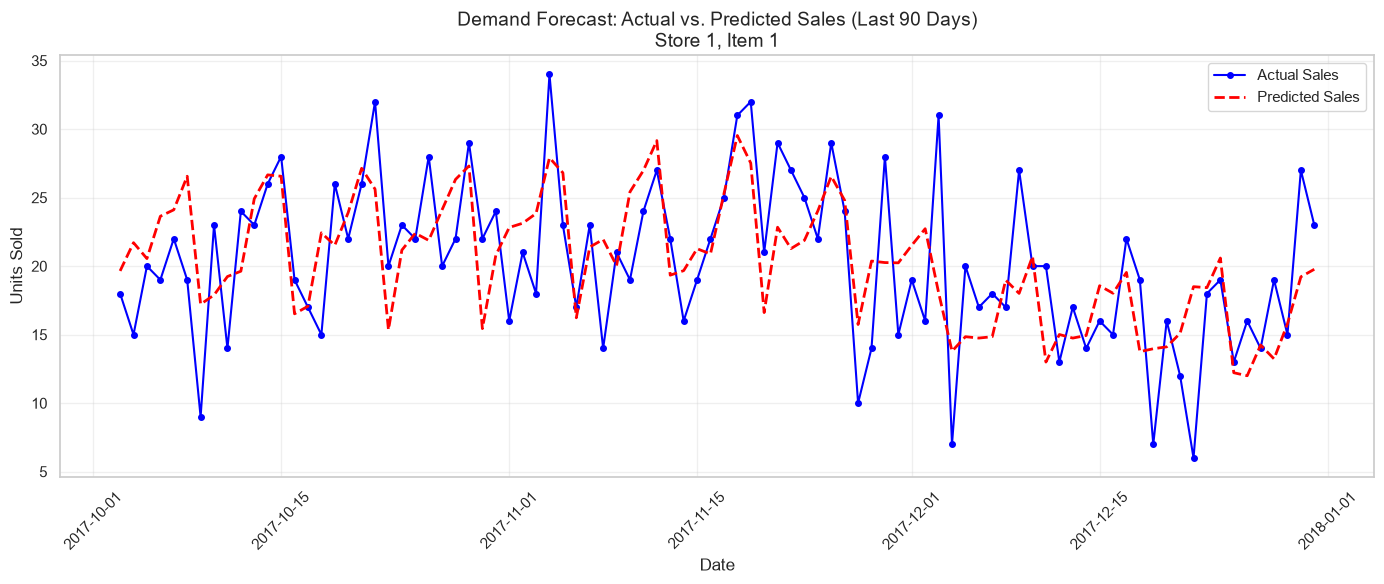


📦 INVENTORY OPTIMIZATION RECOMMENDATIONS
📊 Average Daily Demand Forecast: 20.38 units/day
📉 Demand Variability (Std Dev):  4.42 units
⏱️  Supplier Lead Time:            7 days
🎯 Target Service Level:          95% (Z-score: 1.64)
--------------------------------------------------
🛡️  RECOMMENDED SAFETY STOCK:      20.0 units
🚨 REORDER POINT (ROP):            162.0 units
--------------------------------------------------
💡 ACTIONABLE INSIGHT:
   When the inventory for Item 1 in Store 1 drops to 162.0 units,
   immediately place a new order. The 20.0 units of safety stock
   will protect you from unexpected demand spikes during the 7-day lead time.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# ==========================================
# STEP 8: VISUALIZE PREDICTIONS VS ACTUALS
# ==========================================
# Create a dataframe to easily plot the last 90 days
results_df = pd.DataFrame({
    'Date': y_test.index,
    'Actual Sales': y_test.values,
    'Predicted Sales': predictions
})

plt.figure(figsize=(14, 6))
plt.plot(results_df['Date'], results_df['Actual Sales'], label='Actual Sales', color='blue', marker='o', markersize=4)
plt.plot(results_df['Date'], results_df['Predicted Sales'], label='Predicted Sales', color='red', linestyle='--', linewidth=2)

plt.title('Demand Forecast: Actual vs. Predicted Sales (Last 90 Days)\nStore 1, Item 1', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Units Sold', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 9: INVENTORY OPTIMIZATION (Business Logic)
# ==========================================
print("\n" + "="*50)
print("📦 INVENTORY OPTIMIZATION RECOMMENDATIONS")
print("="*50)

# 1. Define Business Assumptions (You can tweak these!)
lead_time_days = 7          # It takes 7 days for a new order to arrive from the supplier
target_service_level = 0.95 # We want to meet customer demand 95% of the time (avoid stockouts)

# 2. Calculate Z-score for the service level (For 95%, Z is approx 1.645)
z_score = norm.ppf(target_service_level)

# 3. Calculate Average Daily Demand and Standard Deviation of Demand
# We use the recent predictions to estimate future average demand
avg_daily_demand = results_df['Predicted Sales'].mean()
std_dev_demand = results_df['Predicted Sales'].std()

# 4. Calculate Safety Stock
# Formula: Z * Standard Deviation of Demand * sqrt(Lead Time)
safety_stock = z_score * std_dev_demand * np.sqrt(lead_time_days)

# 5. Calculate Reorder Point (ROP)
# Formula: (Average Daily Demand * Lead Time) + Safety Stock
reorder_point = (avg_daily_demand * lead_time_days) + safety_stock

# Print the business recommendations
print(f"📊 Average Daily Demand Forecast: {avg_daily_demand:.2f} units/day")
print(f"📉 Demand Variability (Std Dev):  {std_dev_demand:.2f} units")
print(f"⏱️  Supplier Lead Time:            {lead_time_days} days")
print(f"🎯 Target Service Level:          {target_service_level*100:.0f}% (Z-score: {z_score:.2f})")
print("-" * 50)
print(f"🛡️  RECOMMENDED SAFETY STOCK:      {np.ceil(safety_stock)} units")
print(f"🚨 REORDER POINT (ROP):            {np.ceil(reorder_point)} units")
print("-" * 50)
print("💡 ACTIONABLE INSIGHT:")
print(f"   When the inventory for Item 1 in Store 1 drops to {np.ceil(reorder_point)} units,")
print(f"   immediately place a new order. The {np.ceil(safety_stock)} units of safety stock")
print(f"   will protect you from unexpected demand spikes during the {lead_time_days}-day lead time.")